# 

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/heeraldedhia/groceries-dataset/Groceries_dataset.csv


In [2]:
df = pd.read_csv('/kaggle/input/datasets/heeraldedhia/groceries-dataset/Groceries_dataset.csv')

In [3]:
df.head(10)

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk
5,4941,14-02-2015,rolls/buns
6,4501,08-05-2015,other vegetables
7,3803,23-12-2015,pot plants
8,2762,20-03-2015,whole milk
9,4119,12-02-2015,tropical fruit


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38765 entries, 0 to 38764
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Member_number    38765 non-null  int64 
 1   Date             38765 non-null  object
 2   itemDescription  38765 non-null  object
dtypes: int64(1), object(2)
memory usage: 908.7+ KB


In [5]:
df.shape

(38765, 3)

Dataset Preparation

In [6]:
df.groupby(['Member_number', 'Date'])['itemDescription'].apply(list)

Member_number  Date      
1000           15-03-2015    [sausage, whole milk, semi-finished bread, yog...
               24-06-2014                    [whole milk, pastry, salty snack]
               24-07-2015                       [canned beer, misc. beverages]
               25-11-2015                          [sausage, hygiene articles]
               27-05-2015                           [soda, pickled vegetables]
                                                   ...                        
4999           24-01-2015    [tropical fruit, berries, other vegetables, yo...
               26-12-2015                               [bottled water, herbs]
5000           09-03-2014                      [fruit/vegetable juice, onions]
               10-02-2015         [soda, root vegetables, semi-finished bread]
               16-11-2014                     [bottled beer, other vegetables]
Name: itemDescription, Length: 14963, dtype: object

In [7]:
basket_df = df.groupby(['Member_number', 'Date']).agg(
    basket_size = ('itemDescription', 'size'),
    unique_items = ('itemDescription', 'nunique'),
    items = ('itemDescription', list)
).reset_index()

In [8]:
basket_df.head(20)

,Member_number,Date,basket_size,unique_items,items
0,1000,15-03-2015,4,4,"[sausage, whole milk, semi-finished bread, yog..."
1,1000,24-06-2014,3,3,"[whole milk, pastry, salty snack]"
2,1000,24-07-2015,2,2,"[canned beer, misc. beverages]"
3,1000,25-11-2015,2,2,"[sausage, hygiene articles]"
4,1000,27-05-2015,2,2,"[soda, pickled vegetables]"
5,1001,02-05-2015,2,2,"[frankfurter, curd]"
6,1001,07-02-2014,3,3,"[sausage, whole milk, rolls/buns]"
7,1001,12-12-2014,2,2,"[whole milk, soda]"
8,1001,14-04-2015,2,2,"[beef, white bread]"
9,1001,20-01-2015,3,3,"[frankfurter, soda, whipped/sour cream]"


In [9]:
basket_df.shape

(14963, 5)

Exploratory Data Analysis

In [10]:
#Average items per trip
basket_df['basket_size'].describe()

count    14963.000000
mean         2.590724
std          1.117469
min          2.000000
25%          2.000000
50%          2.000000
75%          3.000000
max         11.000000
Name: basket_size, dtype: float64

In [11]:
#Distribution plot
import matplotlib.pyplot as plt
import seaborn as sns

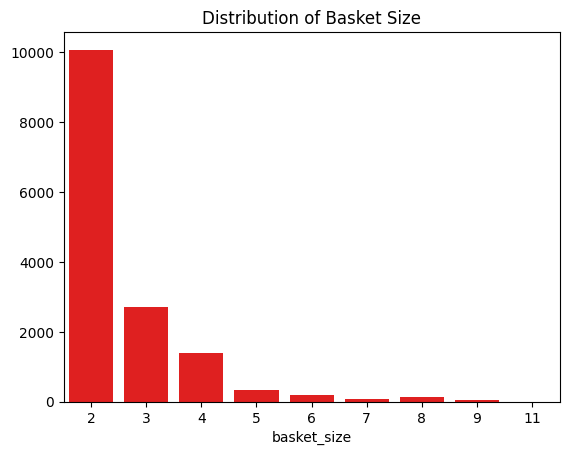

In [12]:
basket_counts = basket_df['basket_size'].value_counts().sort_index()
sns.barplot(x=basket_counts.index, y=basket_counts.values, color='red')
plt.title('Distribution of Basket Size')
plt.show()

In [13]:
#Average basket per member
basket_df.groupby('Member_number')['basket_size'].mean().head(20)

Member_number
1000    2.600000
1001    2.400000
1002    2.000000
1003    2.000000
1004    2.625000
1005    2.000000
1006    3.750000
1008    6.000000
1009    2.250000
1010    2.400000
1011    4.333333
1012    2.750000
1013    2.375000
1014    2.500000
1015    2.333333
1016    2.750000
1017    2.200000
1018    2.000000
1019    2.000000
1020    3.333333
Name: basket_size, dtype: float64

In [14]:
#Total trips per member
basket_df.groupby('Member_number')['Date'].nunique().head(20)

Member_number
1000    5
1001    5
1002    4
1003    4
1004    8
1005    2
1006    4
1008    2
1009    4
1010    5
1011    3
1012    4
1013    8
1014    4
1015    3
1016    4
1017    5
1018    4
1019    1
1020    3
Name: Date, dtype: int64

In [15]:
#Top 10 items sold
df['itemDescription'].value_counts().head(10)

itemDescription
whole milk          2502
other vegetables    1898
rolls/buns          1716
soda                1514
yogurt              1334
root vegetables     1071
tropical fruit      1032
bottled water        933
sausage              924
citrus fruit         812
Name: count, dtype: int64

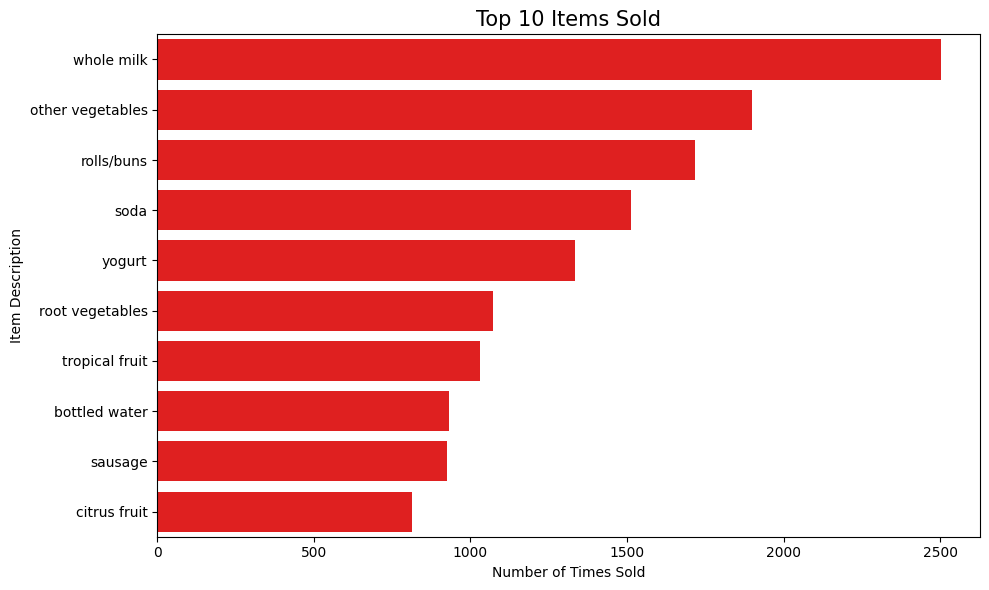

In [16]:
#Visualization of top 10 items sold
top10 = df['itemDescription'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(y=top10.index, x=top10.values, orient='h', color='red')

plt.title('Top 10 Items Sold', fontsize=15)
plt.xlabel('Number of Times Sold')
plt.ylabel('Item Description')
plt.tight_layout()
plt.show()

APRIORI

In [17]:
from mlxtend.frequent_patterns import apriori, association_rules

import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)

In [18]:
#Basket format
basket = df.groupby(['Member_number', 'Date'])['itemDescription'].apply(list)
basket_matrix = basket.str.join('|').str.get_dummies()

In [19]:
basket_matrix.head()

Instant food products  UHT-milk  abrasive cleaner  \
Member_number Date                                                            
1000          15-03-2015                      0         0                 0   
              24-06-2014                      0         0                 0   
              24-07-2015                      0         0                 0   
              25-11-2015                      0         0                 0   
              27-05-2015                      0         0                 0   

                          artif. sweetener  baby cosmetics  bags  \
Member_number Date                                                 
1000          15-03-2015                 0               0     0   
              24-06-2014                 0               0     0   
              24-07-2015                 0               0     0   
              25-11-2015                 0               0     0   
              27-05-2015                 0               0     0   

                          baking powder  bathroom cleaner  beef  berries  ...  \
Member_number Date                                                        ...   
1000          15-03-2015              0                 0     0        0  ...   
              24-06-2014              0                 0     0        0  ...   
              24-07-2015              0                 0     0        0  ...   
              25-11-2015              0                 0     0        0  ...   
              27-05-2015              0                 0     0        0  ...   

                          turkey  vinegar  waffles  whipped/sour cream  \
Member_number Date                                                       
1000          15-03-2015       0        0        0                   0   
              24-06-2014       0        0        0                   0   
              24-07-2015       0        0        0                   0   
              25-11-2015       0        0        0                   0   
              27-05-2015       0        0        0                   0   

                          whisky  white bread  white wine  whole milk  yogurt  \
Member_number Date                                                              
1000          15-03-2015       0            0           0           1       1   
              24-06-2014       0            0           0           1       0   
              24-07-2015       0            0           0           0       0   
              25-11-2015       0            0           0           0       0   
              27-05-2015       0            0           0           0       0   

                          zwieback  
Member_number Date                  
1000          15-03-2015         0  
              24-06-2014         0  
              24-07-2015         0  
              25-11-2015         0  
              27-05-2015         0  

[5 rows x 167 columns]

In [20]:
#Frequent Itemsets
frequent_itemsets = apriori(basket_matrix, min_support=0.001, use_colnames=True)

In [21]:
#Association rules
rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1.0)

In [22]:
rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(UHT-milk),(tropical fruit),0.021386,0.067767,0.001537,0.071875,1.060617,1.0,8.785064e-05,1.004426,0.058402,0.017544,0.004406,0.047279
1,(tropical fruit),(UHT-milk),0.067767,0.021386,0.001537,0.022682,1.060617,1.0,8.785064e-05,1.001326,0.061307,0.017544,0.001325,0.047279
2,(beef),(brown bread),0.033950,0.037626,0.001537,0.045276,1.203301,1.0,2.597018e-04,1.008012,0.174891,0.021947,0.007949,0.043064
3,(brown bread),(beef),0.037626,0.033950,0.001537,0.040853,1.203301,1.0,2.597018e-04,1.007196,0.175559,0.021947,0.007145,0.043064
4,(citrus fruit),(beef),0.053131,0.033950,0.001804,0.033962,1.000349,1.0,6.297697e-07,1.000012,0.000369,0.021160,0.000012,0.043556


In [23]:
rules.shape

(240, 14)

In [24]:
rules = rules[rules['antecedents'].apply(len)>=1]
rules = rules[rules['consequents'].apply(len)>=1]
rules = rules.sort_values('lift', ascending=False).head(20)

In [25]:
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
238,(sausage),"(whole milk, yogurt)",0.060349,0.011161,0.001470,0.024363,2.182917,1.0,0.000797,1.013532,0.576701,0.020992,0.013351,0.078050
235,"(whole milk, yogurt)",(sausage),0.011161,0.060349,0.001470,0.131737,2.182917,1.0,0.000797,1.082219,0.548014,0.020992,0.075973,0.078050
234,"(whole milk, sausage)",(yogurt),0.008955,0.085879,0.001470,0.164179,1.911760,1.0,0.000701,1.093681,0.481231,0.015748,0.085657,0.090650
239,(yogurt),"(whole milk, sausage)",0.085879,0.008955,0.001470,0.017121,1.911760,1.0,0.000701,1.008307,0.521727,0.015748,0.008239,0.090650
86,(citrus fruit),(specialty chocolate),0.053131,0.015973,0.001403,0.026415,1.653762,1.0,0.000555,1.010726,0.417500,0.020731,0.010612,0.057141
87,(specialty chocolate),(citrus fruit),0.015973,0.053131,0.001403,0.087866,1.653762,1.0,0.000555,1.038081,0.401735,0.020731,0.036684,0.057141
236,"(yogurt, sausage)",(whole milk),0.005748,0.157923,0.001470,0.255814,1.619866,1.0,0.000563,1.131541,0.384877,0.009065,0.116250,0.132562
237,(whole milk),"(yogurt, sausage)",0.157923,0.005748,0.001470,0.009310,1.619866,1.0,0.000563,1.003596,0.454430,0.009065,0.003583,0.132562
123,(tropical fruit),(flour),0.067767,0.009757,0.001069,0.015779,1.617141,1.0,0.000408,1.006118,0.409366,0.013986,0.006081,0.062684
122,(flour),(tropical fruit),0.009757,0.067767,0.001069,0.109589,1.617141,1.0,0.000408,1.046969,0.385385,0.013986,0.044862,0.062684


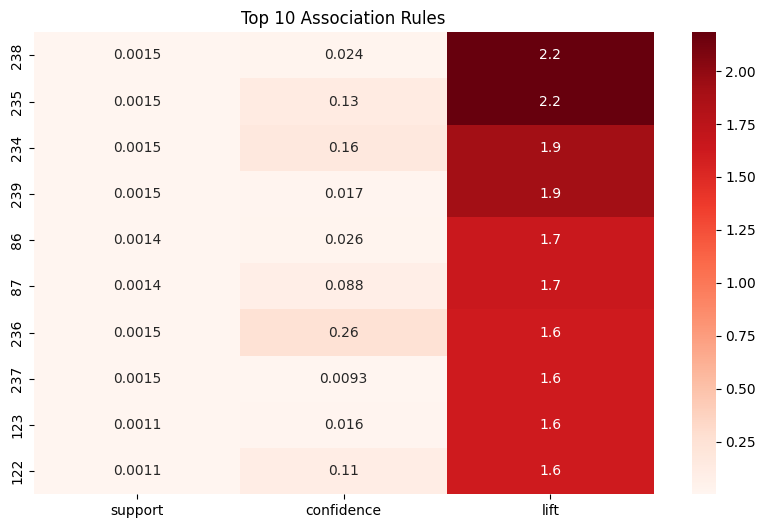

In [26]:
top_rules = rules.head(10)
plt.figure(figsize=(10,6))
sns.heatmap(top_rules[['support','confidence','lift']],annot=True,cmap='Reds')
plt.title('Top 10 Association Rules')
plt.show()

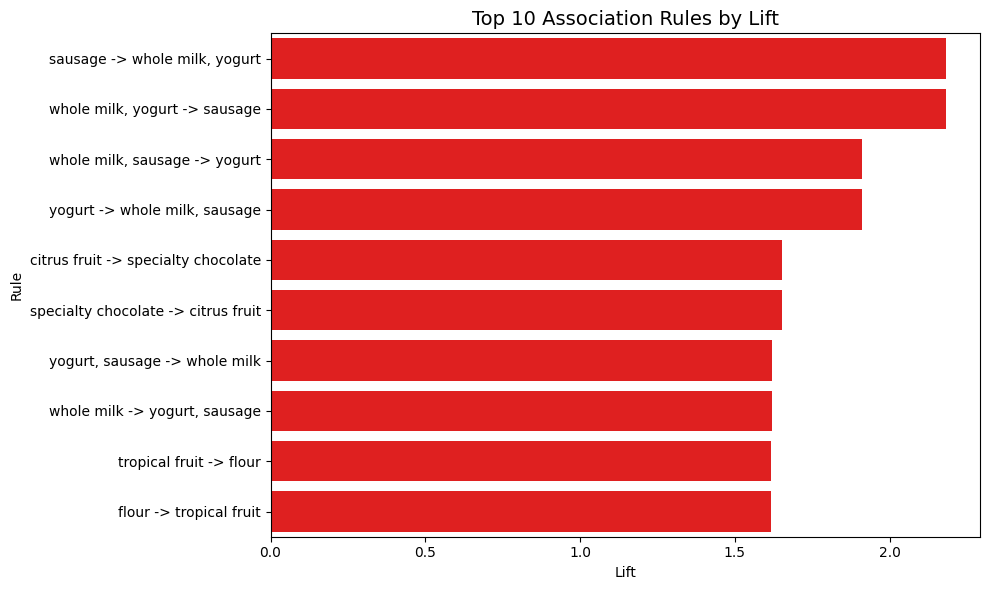

In [27]:
top_rules = rules.head(10).copy()

top_rules['rule'] = top_rules['antecedents'].apply(lambda x: ', '.join(list(x))) + ' -> ' + \
                    top_rules['consequents'].apply(lambda x: ', '.join(list(x)))

plt.figure(figsize=(10, 6))
sns.barplot(y='rule', x='lift', data=top_rules, color='red')

plt.title('Top 10 Association Rules by Lift', fontsize=14)
plt.xlabel('Lift')
plt.ylabel('Rule')
plt.tight_layout()
plt.show()

Customers that buy sausage are 2.2x more likely to buy whole milk and yogurt.
Customers that buy whole milk and yogurt are 2.2x more likely to buy sausage.
Customers that buy whole milk and sausage are 1.9x more likely to buy yogurt.